<a href="https://colab.research.google.com/github/Pankaj8076/Finance-Revenue-Performance-Analytics/blob/main/Finance_Revenue_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas matplotlib seaborn -q

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('outputs', exist_ok=True)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 150

COLORS = {
    'blue'   : '#2196F3',
    'green'  : '#4CAF50',
    'orange' : '#FF9800',
    'red'    : '#F44336',
    'purple' : '#9C27B0',
}
print("✅ Libraries Loaded!")

✅ Libraries Loaded!


In [2]:
df = pd.read_csv('/content/sales_revenue_data.csv')

df['date'] = pd.to_datetime(df['date'])
df['month_name'] = df['date'].dt.strftime('%b')
df['quarter'] = df['date'].dt.quarter
df['quarter_name'] = 'Q' + df['quarter'].astype(str)
df['gross_profit'] = df['revenue'] - df['cogs']
df['gross_margin_pct'] = (df['gross_profit'] / df['revenue'] * 100).round(2)

print(f"✅ Data Loaded Successfully!")
print(f"   Total Records : {len(df)}")
print(f"   Total Revenue : ₹{df['revenue'].sum():,.0f}")
df.head()

✅ Data Loaded Successfully!
   Total Records : 120
   Total Revenue : ₹23,991,000


,order_id,date,region,product_category,product_name,sales_rep,quantity,unit_price,revenue,discount_pct,cogs,customer_segment,month_name,quarter,quarter_name,gross_profit,gross_margin_pct
0,ORD001,2024-01-03,North,Software,CRM Pro,Rahul Sharma,5,12000,60000,5,36000,Enterprise,Jan,1,Q1,24000,40.0
1,ORD002,2024-01-05,South,Hardware,Laptop Elite,Priya Nair,3,55000,165000,0,99000,SMB,Jan,1,Q1,66000,40.0
2,ORD003,2024-01-08,West,Services,IT Support Annual,Amit Patel,1,80000,80000,10,32000,Enterprise,Jan,1,Q1,48000,60.0
3,ORD004,2024-01-10,East,Software,Analytics Suite,Sneha Roy,2,25000,50000,0,20000,Mid-Market,Jan,1,Q1,30000,60.0
4,ORD005,2024-01-12,North,Hardware,Server Pro,Rahul Sharma,1,120000,120000,5,72000,Enterprise,Jan,1,Q1,48000,40.0


In [3]:
total_revenue   = df['revenue'].sum()
total_profit    = df['gross_profit'].sum()
total_orders    = df['order_id'].nunique()
avg_order_value = df['revenue'].mean()
avg_margin      = df['gross_margin_pct'].mean()
top_region      = df.groupby('region')['revenue'].sum().idxmax()
top_rep         = df.groupby('sales_rep')['revenue'].sum().idxmax()
top_category    = df.groupby('product_category')['revenue'].sum().idxmax()

print("=" * 45)
print("      📊 KPI SUMMARY DASHBOARD")
print("=" * 45)
print(f"  Total Revenue      : ₹{total_revenue:,.0f}")
print(f"  Total Gross Profit : ₹{total_profit:,.0f}")
print(f"  Total Orders       : {total_orders}")
print(f"  Avg Order Value    : ₹{avg_order_value:,.0f}")
print(f"  Avg Gross Margin   : {avg_margin:.1f}%")
print(f"  Top Region         : {top_region}")
print(f"  Top Sales Rep      : {top_rep}")
print(f"  Top Category       : {top_category}")
print("=" * 45)

      📊 KPI SUMMARY DASHBOARD
  Total Revenue      : ₹23,991,000
  Total Gross Profit : ₹12,006,400
  Total Orders       : 120
  Avg Order Value    : ₹199,925
  Avg Gross Margin   : 50.0%
  Top Region         : North
  Top Sales Rep      : Rahul Sharma
  Top Category       : Hardware


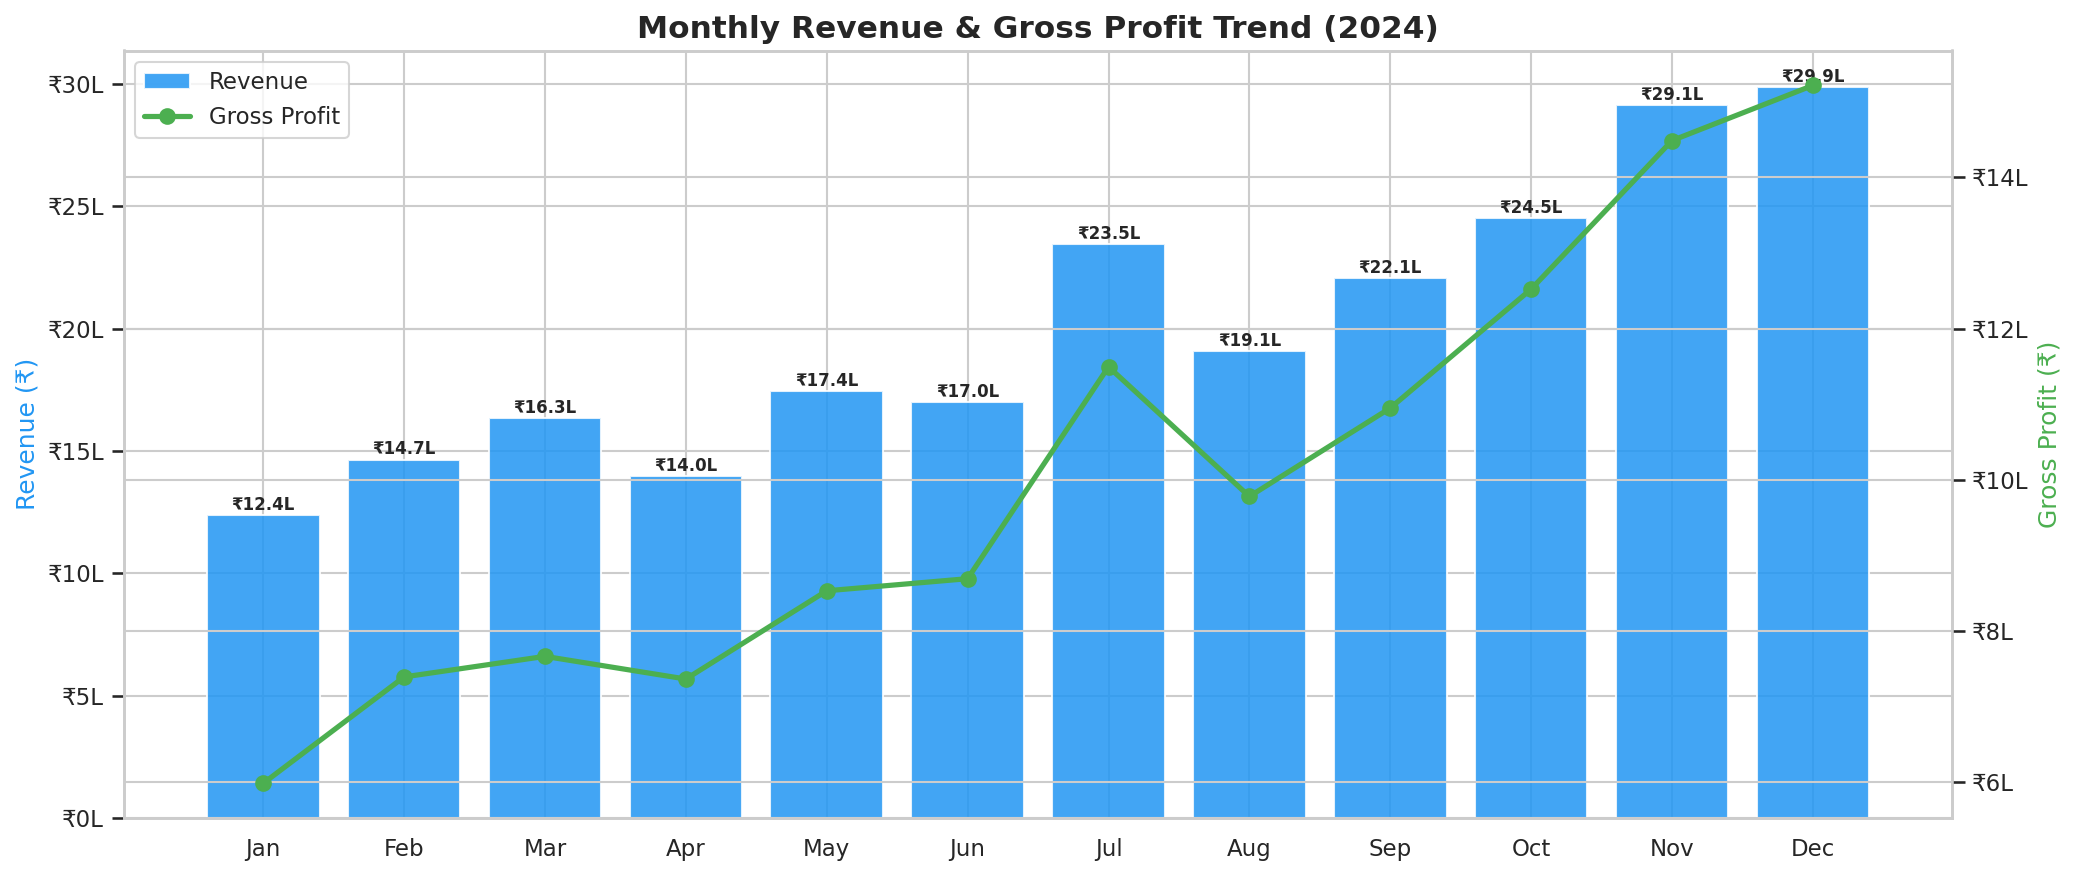

✅ Chart 1 Done!


In [4]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

monthly = (df.groupby('month_name')
             .agg(revenue=('revenue','sum'),
                  profit=('gross_profit','sum'))
             .reindex(month_order)
             .reset_index())

fig, ax1 = plt.subplots(figsize=(14, 6))

bars = ax1.bar(monthly['month_name'], monthly['revenue'],
               color=COLORS['blue'], alpha=0.85, label='Revenue')

ax2 = ax1.twinx()
ax2.plot(monthly['month_name'], monthly['profit'],
         color=COLORS['green'], marker='o',
         linewidth=2.5, markersize=7, label='Gross Profit')

for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.,
             height + 5000,
             f'₹{height/100000:.1f}L',
             ha='center', va='bottom',
             fontsize=8, fontweight='bold')

ax1.set_ylabel('Revenue (₹)', color=COLORS['blue'])
ax2.set_ylabel('Gross Profit (₹)', color=COLORS['green'])
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'₹{x/100000:.0f}L'))
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'₹{x/100000:.0f}L'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Monthly Revenue & Gross Profit Trend (2024)',
          fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/01_monthly_revenue_trend.png', bbox_inches='tight')
plt.show()
print("✅ Chart 1 Done!")

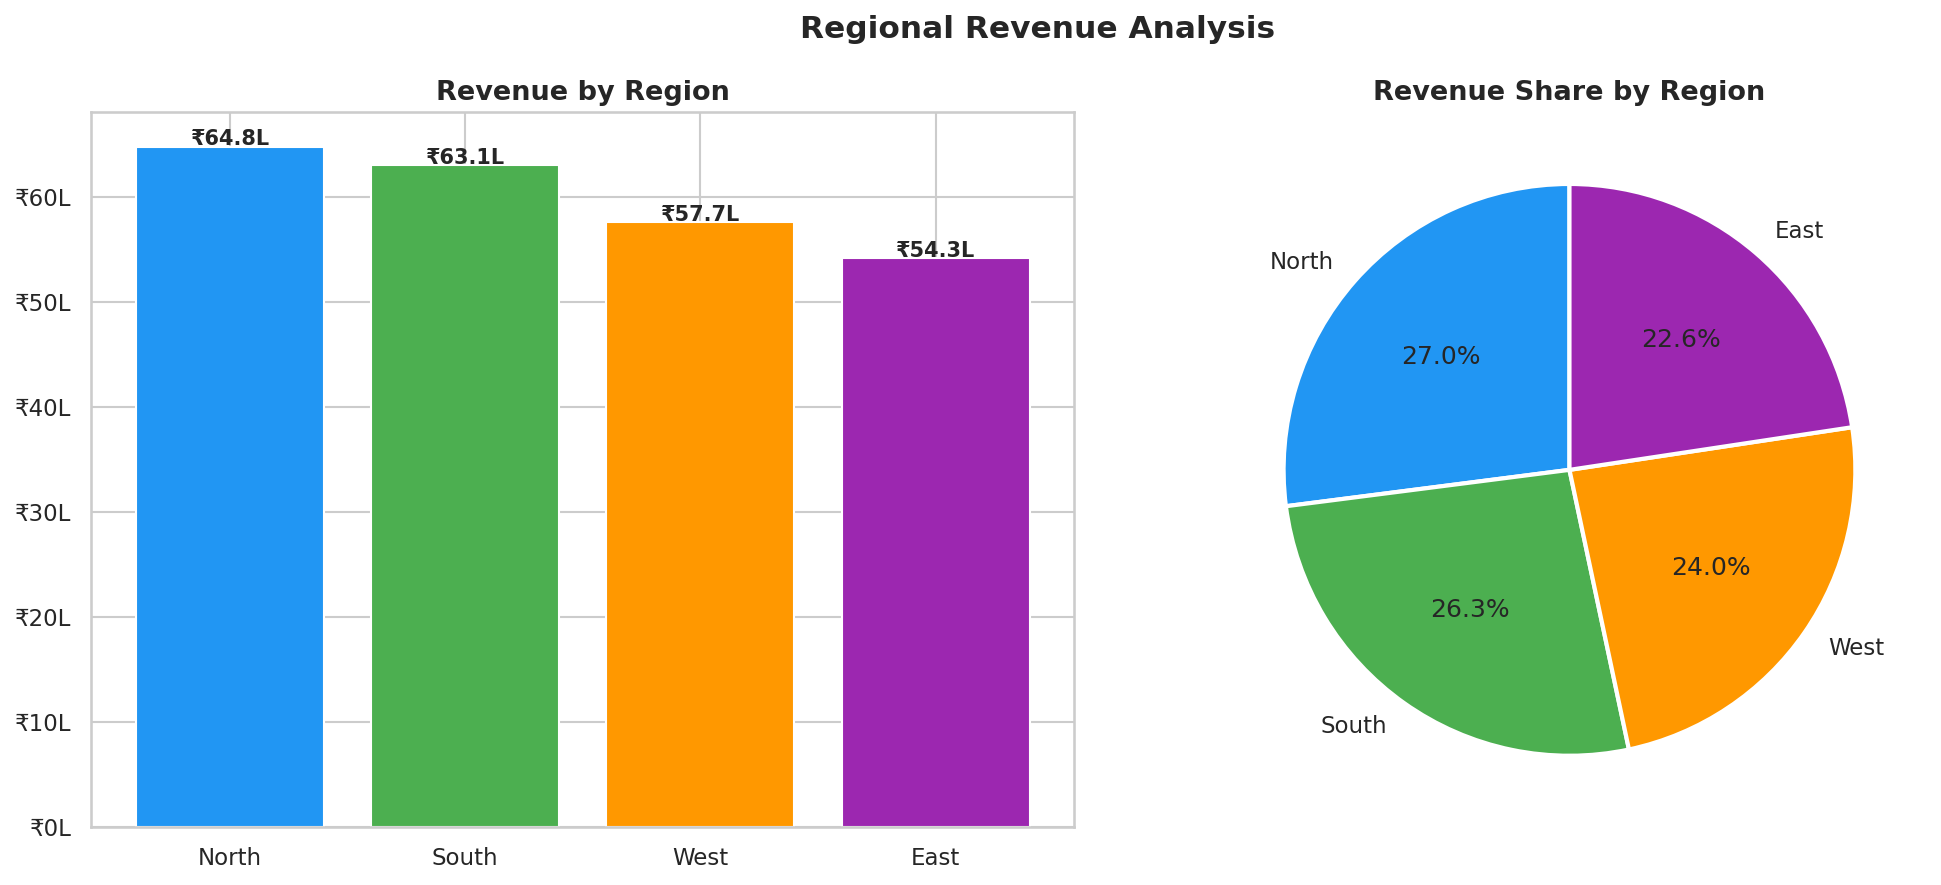

✅ Chart 2 Done!


In [5]:
region_df = (df.groupby('region')
               .agg(revenue=('revenue','sum'),
                    profit=('gross_profit','sum'))
               .sort_values('revenue', ascending=False)
               .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
region_colors = [COLORS['blue'], COLORS['green'],
                 COLORS['orange'], COLORS['purple']]

bars = axes[0].bar(region_df['region'], region_df['revenue'],
                   color=region_colors, edgecolor='white')

for bar, val in zip(bars, region_df['revenue']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 10000,
                 f'₹{val/100000:.1f}L',
                 ha='center', fontsize=10, fontweight='bold')

axes[0].set_title('Revenue by Region', fontsize=13, fontweight='bold')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'₹{x/100000:.0f}L'))

axes[1].pie(region_df['revenue'],
            labels=region_df['region'],
            colors=region_colors,
            autopct='%1.1f%%',
            startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))

axes[1].set_title('Revenue Share by Region', fontsize=13, fontweight='bold')

plt.suptitle('Regional Revenue Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/02_revenue_by_region.png', bbox_inches='tight')
plt.show()
print("✅ Chart 2 Done!")

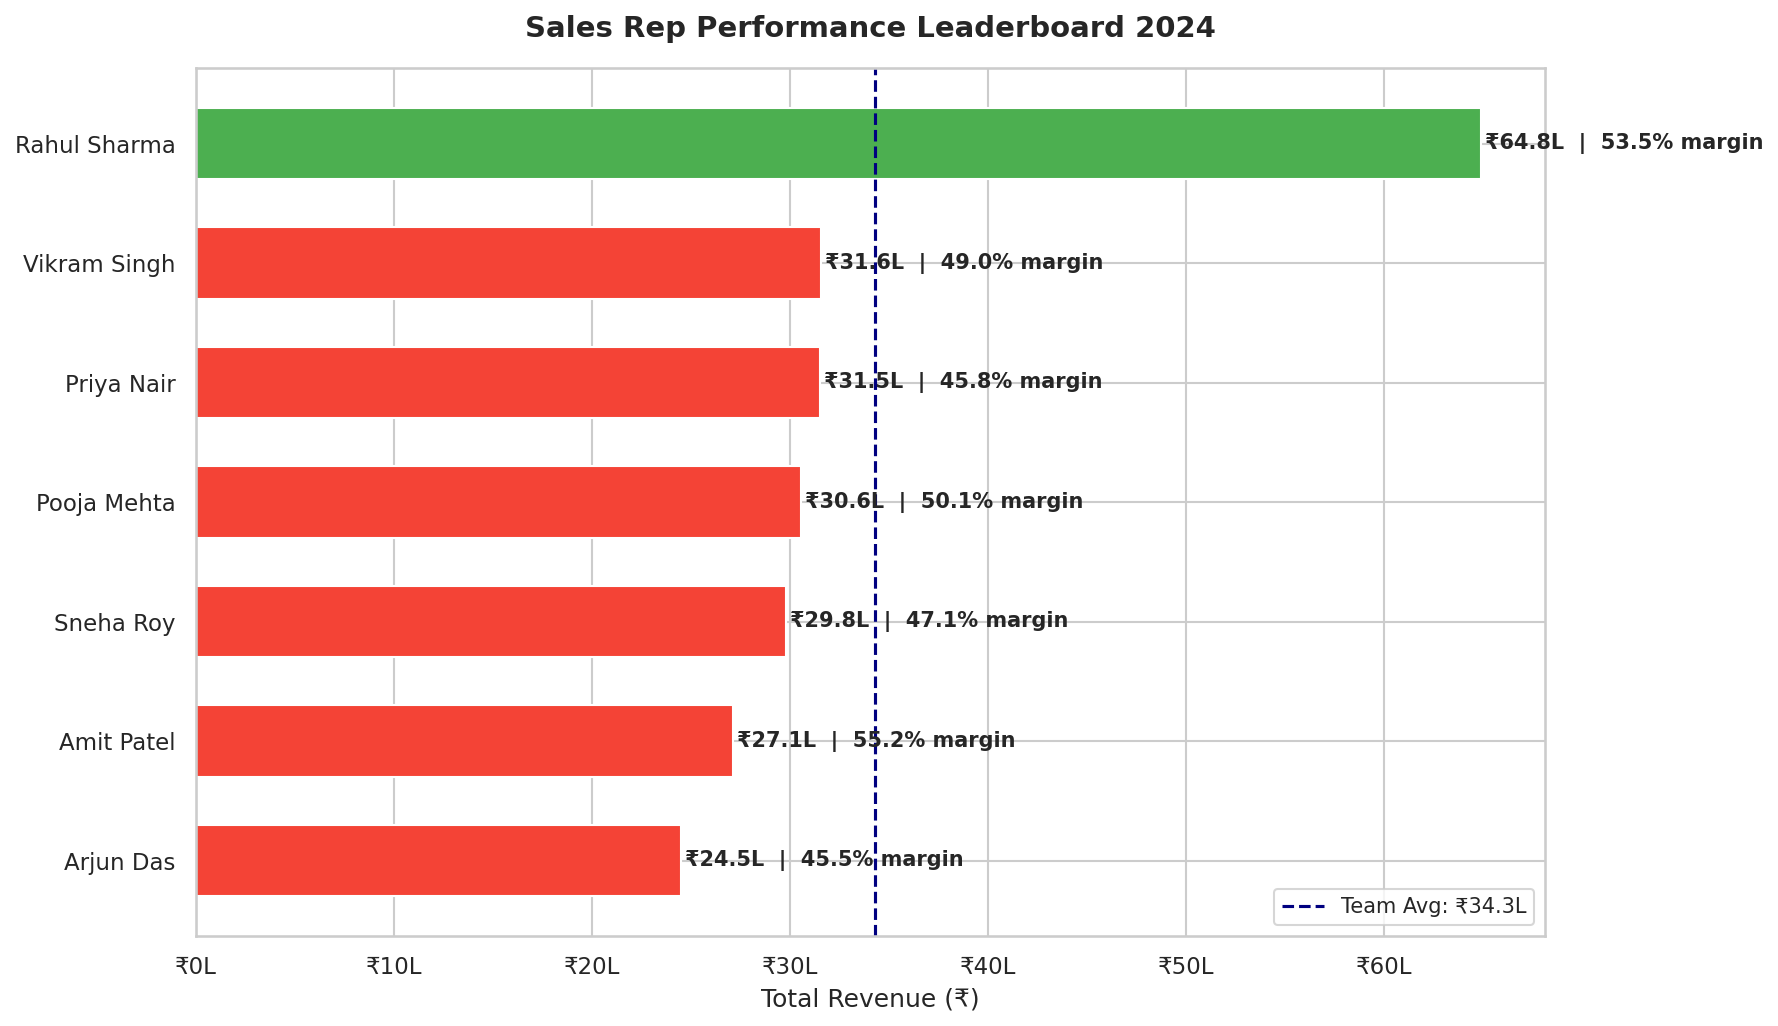

✅ Chart 3 Done!


In [6]:
rep_df = (df.groupby('sales_rep')
            .agg(revenue=('revenue','sum'),
                 profit=('gross_profit','sum'),
                 orders=('order_id','count'))
            .sort_values('revenue', ascending=True)
            .reset_index())

rep_df['margin_pct'] = (rep_df['profit'] / rep_df['revenue'] * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 7))

bar_colors = [COLORS['red'] if r < rep_df['revenue'].mean()
              else COLORS['green'] for r in rep_df['revenue']]

h_bars = ax.barh(rep_df['sales_rep'], rep_df['revenue'],
                  color=bar_colors, edgecolor='white', height=0.6)

for bar, val, margin in zip(h_bars, rep_df['revenue'], rep_df['margin_pct']):
    ax.text(bar.get_width() + 20000,
            bar.get_y() + bar.get_height()/2,
            f'₹{val/100000:.1f}L  |  {margin}% margin',
            va='center', fontsize=10, fontweight='bold')

avg_rev = rep_df['revenue'].mean()
ax.axvline(x=avg_rev, color='navy', linestyle='--',
           linewidth=1.5,
           label=f'Team Avg: ₹{avg_rev/100000:.1f}L')

ax.set_title('Sales Rep Performance Leaderboard 2024',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Revenue (₹)', fontsize=12)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'₹{x/100000:.0f}L'))
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('outputs/04_sales_rep_leaderboard.png', bbox_inches='tight')
plt.show()
print("✅ Chart 3 Done!")

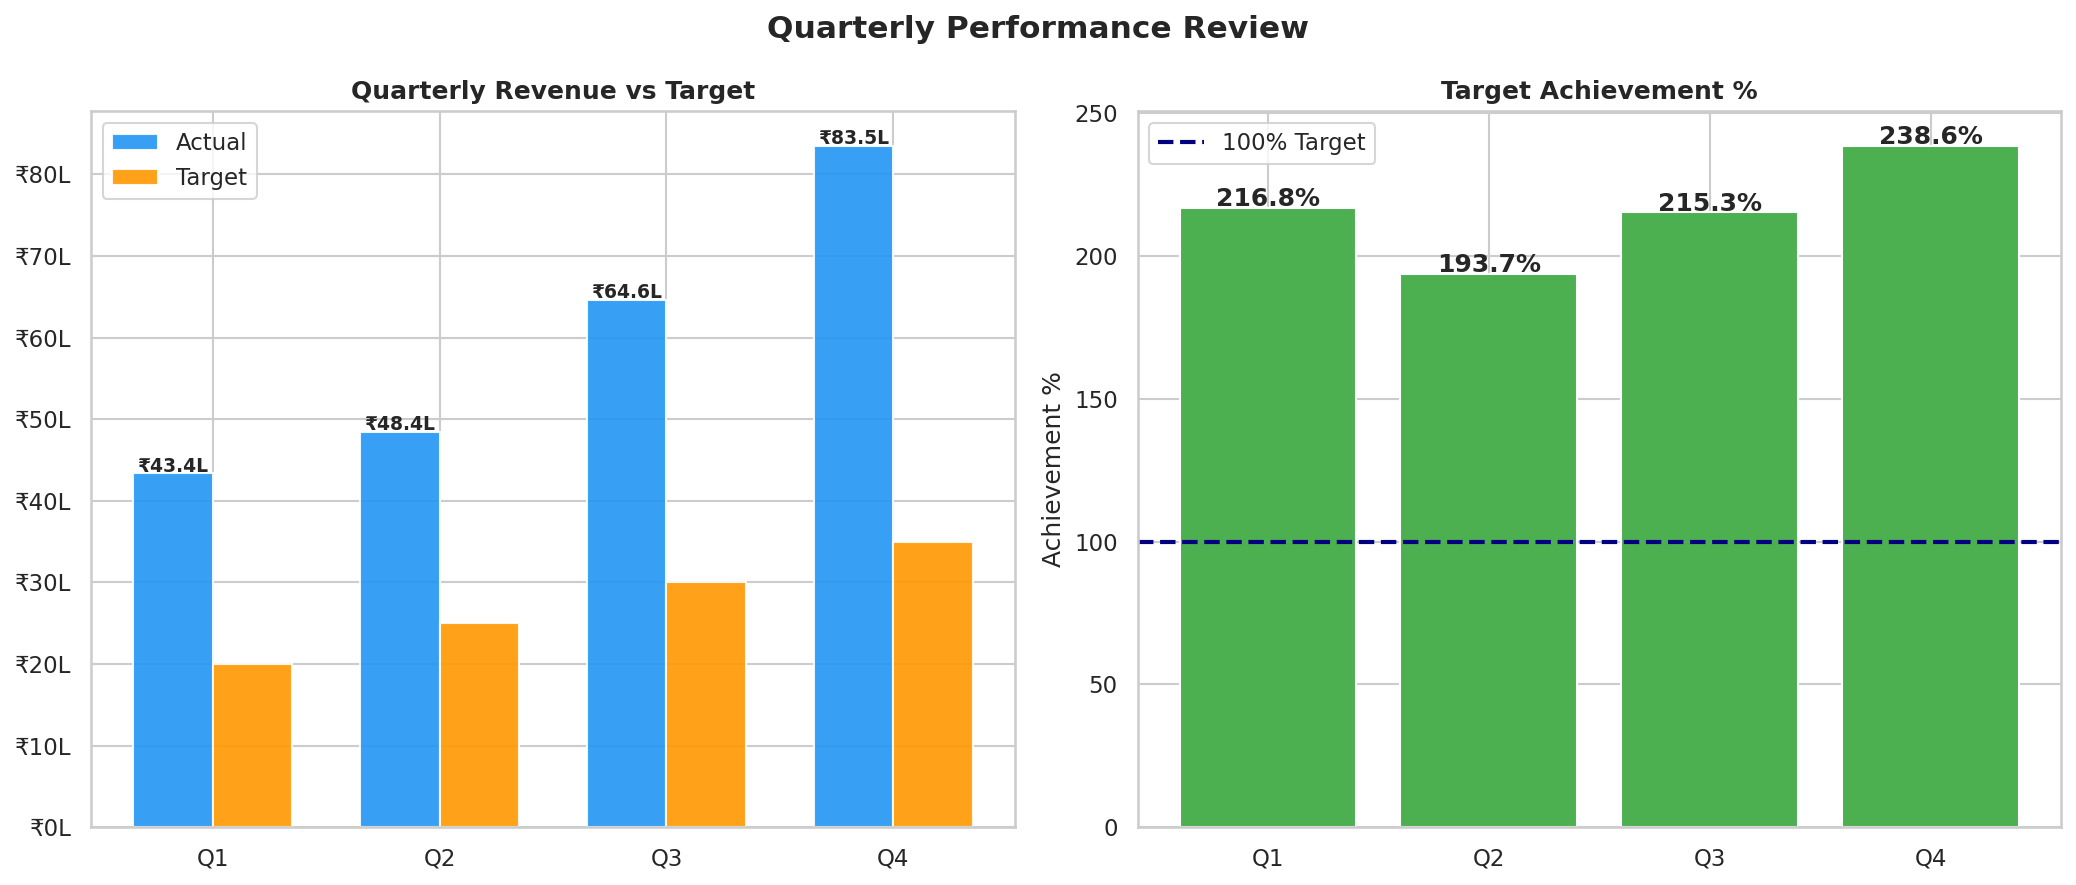

✅ Chart 4 Done!


In [7]:
quarterly = (df.groupby('quarter_name')
               .agg(revenue=('revenue','sum'),
                    profit=('gross_profit','sum'))
               .reset_index())

targets = {'Q1': 2000000, 'Q2': 2500000,
           'Q3': 3000000, 'Q4': 3500000}
quarterly['target'] = quarterly['quarter_name'].map(targets)
quarterly['achievement'] = (quarterly['revenue'] /
                             quarterly['target'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
x = range(len(quarterly))
width = 0.35

bars1 = axes[0].bar([i - width/2 for i in x],
                     quarterly['revenue'], width,
                     label='Actual', color=COLORS['blue'], alpha=0.9)
bars2 = axes[0].bar([i + width/2 for i in x],
                     quarterly['target'], width,
                     label='Target', color=COLORS['orange'], alpha=0.9)

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20000,
                 f'₹{bar.get_height()/100000:.1f}L',
                 ha='center', fontsize=9, fontweight='bold')

axes[0].set_xticks(list(x))
axes[0].set_xticklabels(quarterly['quarter_name'])
axes[0].set_title('Quarterly Revenue vs Target', fontweight='bold')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'₹{x/100000:.0f}L'))
axes[0].legend()

ach_colors = [COLORS['green'] if a >= 100
              else COLORS['red'] for a in quarterly['achievement']]
axes[1].bar(quarterly['quarter_name'],
            quarterly['achievement'], color=ach_colors)
axes[1].axhline(y=100, color='navy', linestyle='--',
                linewidth=2, label='100% Target')

for i, val in enumerate(quarterly['achievement']):
    axes[1].text(i, val + 0.5, f'{val}%',
                 ha='center', fontsize=12, fontweight='bold')

axes[1].set_title('Target Achievement %', fontweight='bold')
axes[1].set_ylabel('Achievement %')
axes[1].legend()

plt.suptitle('Quarterly Performance Review',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/05_quarterly_vs_target.png', bbox_inches='tight')
plt.show()
print("✅ Chart 4 Done!")

In [8]:
best_month  = monthly.loc[monthly['revenue'].idxmax(), 'month_name']
worst_month = monthly.loc[monthly['revenue'].idxmin(), 'month_name']

print("=" * 50)
print("     📋 FINAL BUSINESS INSIGHTS")
print("=" * 50)
print(f"""
  1. REVENUE PERFORMANCE
     • Annual Revenue : ₹{total_revenue:,.0f}
     • Annual Profit  : ₹{total_profit:,.0f}
     • Avg Margin     : {avg_margin:.1f}%

  2. TOP PERFORMERS
     • Best Month     : {best_month}
     • Worst Month    : {worst_month}
     • Top Region     : {top_region}
     • Top Sales Rep  : {top_rep}
     • Top Category   : {top_category}

  3. RECOMMENDATIONS
     • Focus on {worst_month} → fix revenue dip
     • Share {top_rep}'s strategy with team
     • High discounts hurting margins
       → Review discount policy
""")
print("=" * 50)
print("🎉 Analysis Complete! All charts saved!")

     📋 FINAL BUSINESS INSIGHTS

  1. REVENUE PERFORMANCE
     • Annual Revenue : ₹23,991,000
     • Annual Profit  : ₹12,006,400
     • Avg Margin     : 50.0%

  2. TOP PERFORMERS
     • Best Month     : Dec
     • Worst Month    : Jan
     • Top Region     : North
     • Top Sales Rep  : Rahul Sharma
     • Top Category   : Hardware

  3. RECOMMENDATIONS
     • Focus on Jan → fix revenue dip
     • Share Rahul Sharma's strategy with team
     • High discounts hurting margins
       → Review discount policy

🎉 Analysis Complete! All charts saved!
